In [5]:
!pip install -U sentence-transformers textblob

In [6]:
!pip install alibi

In [7]:
import pandas as pd
import numpy as np
from textblob import TextBlob
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


In [8]:
# Load preprocessed dataset
df = pd.read_csv("run_stage_dataset.csv")

# Drop redundant column if needed
if "length" in df.columns:
    df.drop(columns=["length"], inplace=True)

# Normalize stars for optional features
df["stars_norm"] = df["stars"] / 5
df["sentiment_star_gap"] = (df["sentiment"] - df["stars_norm"]).abs()

# Confirm
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59528 entries, 0 to 59527
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   reviewText          59528 non-null  object 
 1   label               59528 non-null  int64  
 2   source              59528 non-null  object 
 3   category            59528 non-null  object 
 4   stars               59528 non-null  float64
 5   verified            59528 non-null  bool   
 6   generated           59528 non-null  bool   
 7   review_length       59528 non-null  int64  
 8   sentiment           59528 non-null  float64
 9   stars_norm          59528 non-null  float64
 10  sentiment_star_gap  59528 non-null  float64
dtypes: bool(2), float64(4), int64(2), object(3)
memory usage: 4.2+ MB


In [9]:
# If input_text is not present, generate it
if "input_text" not in df.columns:
    df["input_text"] = df["category"] + " - " + df["reviewText"]

# Load BERT model (MiniLM)
bert_model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode input text (slow step)
X_bert = bert_model.encode(df["input_text"].tolist(), show_progress_bar=True)


Batches:   0%|          | 0/1861 [00:00<?, ?it/s]

In [10]:
# Metadata features
X_meta = df[["sentiment", "review_length", "stars", "sentiment_star_gap"]].to_numpy()

# Combine BERT + metadata
X_full = np.concatenate([X_bert, X_meta], axis=1)

# Labels
y = df["label"].values


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)

In [12]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [13]:
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["real", "fake"]))

              precision    recall  f1-score   support

        real       0.79      0.90      0.84      7234
        fake       0.80      0.64      0.71      4672

    accuracy                           0.80     11906
   macro avg       0.80      0.77      0.78     11906
weighted avg       0.80      0.80      0.79     11906



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


AUC ROC: 0.868


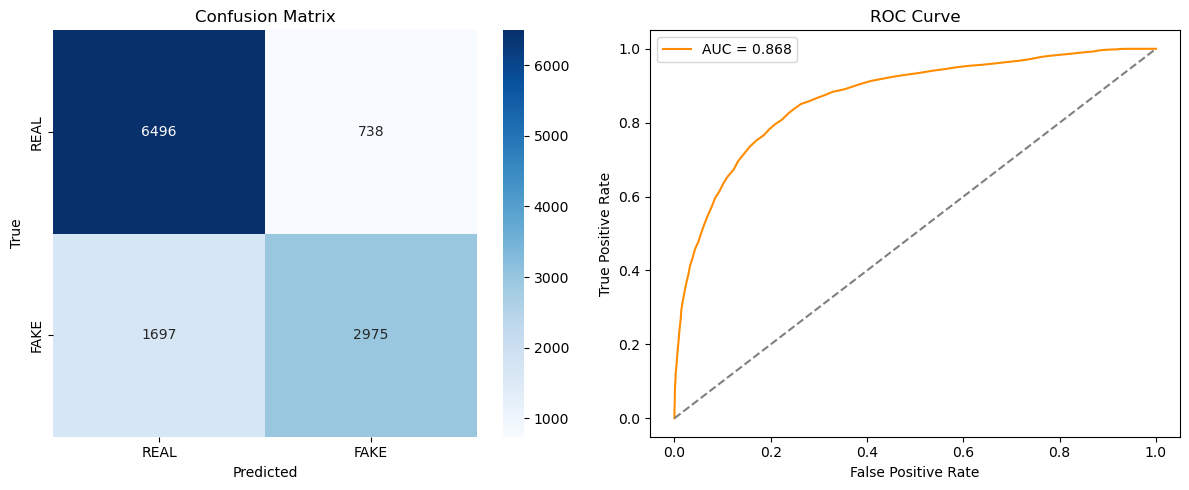

In [14]:
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Probabilities
probas = clf.predict_proba(X_test)[:, 1]

# AUC Score
auc = roc_auc_score(y_test, probas)
print("AUC ROC:", round(auc, 3))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["REAL", "FAKE"], yticklabels=["REAL", "FAKE"], ax=axs[0])
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("True")
axs[0].set_title("Confusion Matrix")

# Plot 2: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, probas)
axs[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}", color="darkorange")
axs[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axs[1].set_xlabel("False Positive Rate")
axs[1].set_ylabel("True Positive Rate")
axs[1].set_title("ROC Curve")
axs[1].legend()

plt.tight_layout()
plt.show()



In [15]:
def test_custom_review(text, category="electronics", stars=3, verbose=True):
    # Compute sentiment and length
    sentiment = TextBlob(text).sentiment.polarity
    length = len(text.split())
    sentiment_gap = abs(sentiment - (stars / 5))

    # Build input
    full_input = f"{category} - {text}"
    emb = bert_model.encode([full_input])
    meta = np.array([[sentiment, length, stars, sentiment_gap]])
    full_features = np.concatenate([emb, meta], axis=1)

    # Predict
    pred = clf.predict(full_features)[0]
    proba = clf.predict_proba(full_features)[0][1]  # Trust score = prob fake

    if verbose:
        print(f"\n📝 Review: {text}")
        print(f"🤖 Predicted: {'FAKE' if pred == 1 else 'REAL'}")
        print(f"🔢 Trust Score (Fake): {proba:.2f}")

    return pred, proba

# Example:
# test_custom_review("This product changed my life!", category="beauty", stars=5)

In [16]:
test_custom_review("fjjfjfjfjw", category="electronics", stars=3)


📝 Review: fjjfjfjfjw
🤖 Predicted: REAL
🔢 Trust Score (Fake): 0.40


(0, 0.4)

In [17]:
test_custom_review("This product is shit", category="electronics", stars=3)


📝 Review: This product is shit
🤖 Predicted: REAL
🔢 Trust Score (Fake): 0.28


(0, 0.28)

In [18]:
test_custom_review("This product is what exactly what I needed. It is convenient, has a perfect size and is not dangerous for my kid. I highly recommend it", category="electronics", stars=1)


📝 Review: This product is what exactly what I needed. It is convenient, has a perfect size and is not dangerous for my kid. I highly recommend it
🤖 Predicted: REAL
🔢 Trust Score (Fake): 0.42


(0, 0.42)

In [19]:
test_custom_review("The fries are dry and not good at all. The kebab is good but has too many toppings and several pieces of meat were very tough.", category="electronics", stars=2)


📝 Review: The fries are dry and not good at all. The kebab is good but has too many toppings and several pieces of meat were very tough.
🤖 Predicted: REAL
🔢 Trust Score (Fake): 0.16


(0, 0.16)

✅ Final SHAP shape : (100, 388)
✅ X_sample shape    : (100, 388)
✅ Feature names     : 388


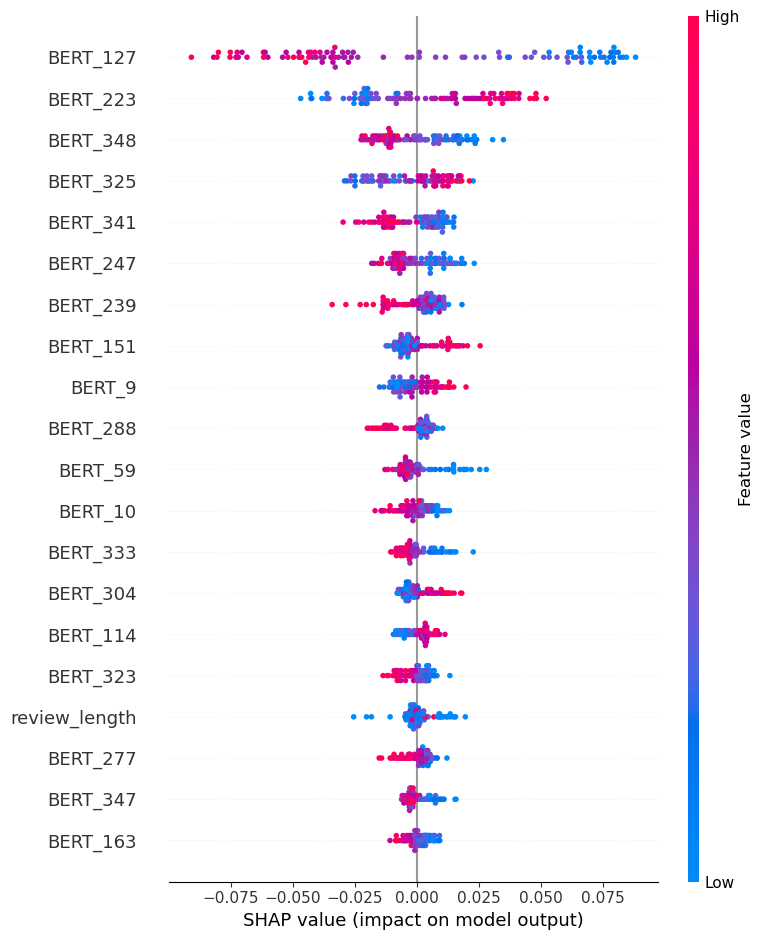

In [20]:
import shap

# 1. Explainer
explainer = shap.TreeExplainer(clf)

# 2. Pick 100 échantillons
X_sample = X_test[:100]

# 3. SHAP values (disable additivity check for RF)
shap_values = explainer.shap_values(X_sample, check_additivity=False)

# 4. ✅ Slice correct pour la classe "FAKE" = 1
# shap_values: (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    # shap_values[1] shape = (100, 388)
    shap_values_fixed = shap_values[1]  # class = 1 (FAKE)
else:
    shap_values_fixed = shap_values[:, :, 1]  # if 3D array returned

# 5. Vérification
print("✅ Final SHAP shape :", shap_values_fixed.shape)
print("✅ X_sample shape    :", X_sample.shape)

# 6. Feature names
bert_dim = X_sample.shape[1] - 4
feature_names = [f"BERT_{i}" for i in range(bert_dim)] + ["sentiment", "review_length", "stars", "sentiment_star_gap"]
print("✅ Feature names     :", len(feature_names))

# 7. 🎯 Summary plot
shap.summary_plot(shap_values_fixed, X_sample, feature_names=feature_names)


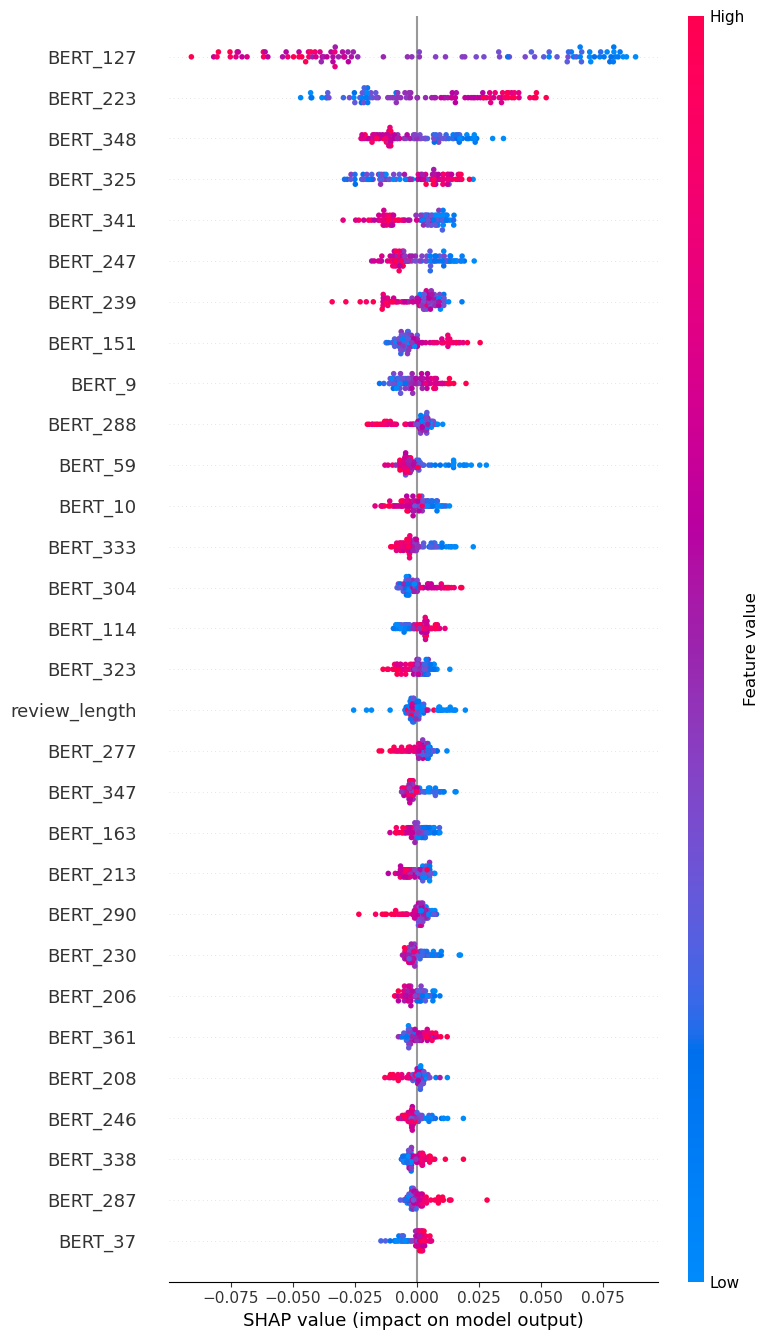

In [21]:
# Afficher uniquement les 30 features les plus importantes
shap.summary_plot(shap_values_fixed, X_sample, feature_names=feature_names, max_display=30)


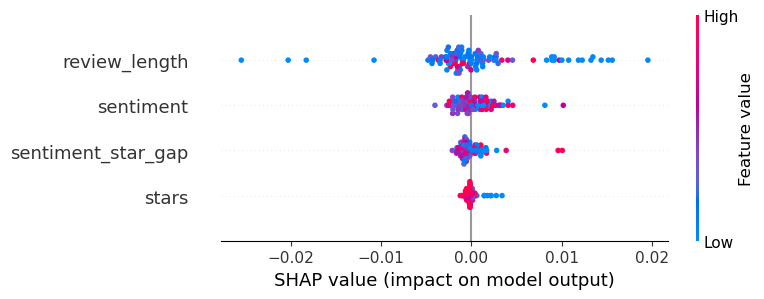

In [22]:
meta_indices = [-4, -3, -2, -1]  # Les 4 dernières colonnes
meta_features = ["sentiment", "review_length", "stars", "sentiment_star_gap"]

shap.summary_plot(
    shap_values_fixed[:, meta_indices], 
    X_sample[:, meta_indices], 
    feature_names=meta_features
)

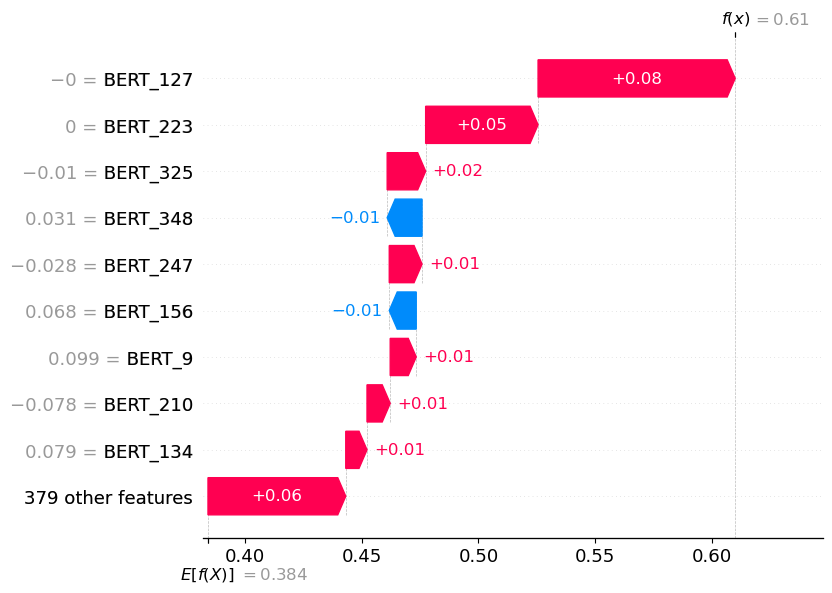

In [23]:
# Index du sample
i = 42

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_fixed[i],
        base_values=explainer.expected_value[1],
        data=X_sample[i],
        feature_names=feature_names
    )
)

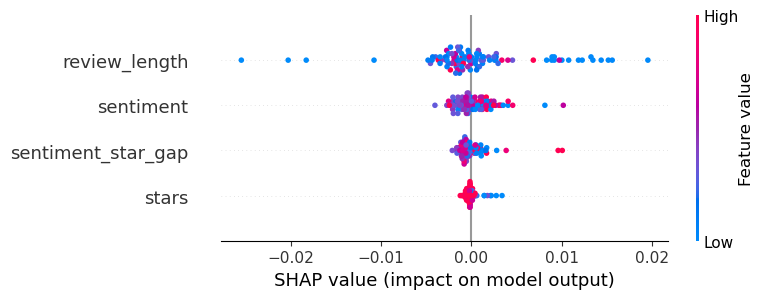

In [24]:
# Summary plot pour les 4 dernières features uniquement
meta_only_idx = [-4, -3, -2, -1]  # Indices des 4 features
shap.summary_plot(shap_values_fixed[:, meta_only_idx], 
                  X_sample[:, meta_only_idx], 
                  feature_names=[feature_names[i] for i in meta_only_idx])


In [25]:
test_custom_review("Absolutely life-changing product. 10/10. Highly recommend to everyone. Will buy again!", 
                   category="beauty", stars=5)



📝 Review: Absolutely life-changing product. 10/10. Highly recommend to everyone. Will buy again!
🤖 Predicted: REAL
🔢 Trust Score (Fake): 0.23


(0, 0.23)

In [26]:
test_custom_review("dddddddn.", 
                   category="restaurant", stars=5)


📝 Review: dddddddn.
🤖 Predicted: REAL
🔢 Trust Score (Fake): 0.38


(0, 0.38)

In [27]:
test_custom_review("I love this product", category="electronics", stars=1)



📝 Review: I love this product
🤖 Predicted: REAL
🔢 Trust Score (Fake): 0.25


(0, 0.25)

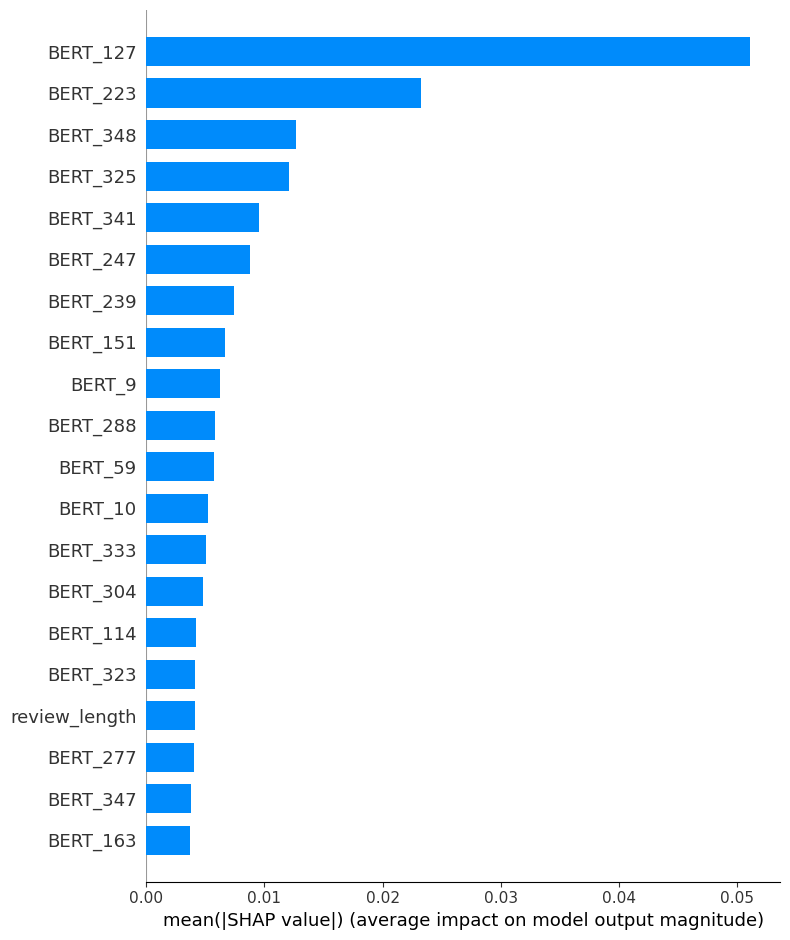

In [28]:
shap.summary_plot(shap_values_fixed, X_sample, feature_names=feature_names, plot_type="bar")


In [29]:
from lime.lime_tabular import LimeTabularExplainer

# Explain only metadata (last 4 features)
meta_indices = [-4, -3, -2, -1]  
meta_features = ["sentiment", "review_length", "stars", "sentiment_star_gap"]

lime_explainer = LimeTabularExplainer(
    training_data=X_train[:, meta_indices],
    feature_names=meta_features,
    mode="classification"
)

exp = lime_explainer.explain_instance(
    X_test[0, meta_indices], 
    lambda x: clf.predict_proba(np.hstack([np.zeros((x.shape[0], X_train.shape[1]-4)), x]))
)
exp.show_in_notebook()

In [30]:
from lime.lime_tabular import LimeTabularExplainer

# Explain only metadata (last 4 features)
meta_indices = [-4, -3, -2, -1]  
meta_features = ["sentiment", "review_length", "stars", "sentiment_star_gap"]

lime_explainer = LimeTabularExplainer(
    training_data=X_train[:, meta_indices],
    feature_names=meta_features,
    mode="classification"
)

exp = lime_explainer.explain_instance(
    X_test[0, meta_indices], 
    lambda x: clf.predict_proba(np.hstack([np.zeros((x.shape[0], X_train.shape[1]-4)), x]))
)
exp.show_in_notebook()

In [31]:
test_custom_review("Wow, just incredible", 
                   category="home", stars=1)


📝 Review: Wow, just incredible
🤖 Predicted: REAL
🔢 Trust Score (Fake): 0.40


(0, 0.4)

In [32]:
import pickle

# Sauvegarde du modèle Random Forest
with open("bert_rf_run_stage_model.pkl", "wb") as f:
    pickle.dump(clf, f)

print("✅ Modèle RandomForest sauvegardé sous 'bert_rf_run_stage_model.pkl'")


✅ Modèle RandomForest sauvegardé sous 'bert_rf_run_stage_model.pkl'


In [33]:
# Pour tester si la prédiction reste identique après sauvegarde
pred_before = clf.predict(X_test[0:1])[0]

# Sauvegarde
with open("bert_rf_run_stage_model.pkl", "wb") as f:
    pickle.dump(clf, f)

# Rechargement
with open("bert_rf_run_stage_model.pkl", "rb") as f:
    clf_loaded = pickle.load(f)

pred_after = clf_loaded.predict(X_test[0:1])[0]

assert pred_before == pred_after
print("✅ Prédiction identique après rechargement")


✅ Prédiction identique après rechargement


In [34]:
import pickle

# 1. Sauvegarde du modèle entraîné
with open("run_stage_model.pkl", "wb") as f:
    pickle.dump(clf, f)

# 2. Sauvegarde du modèle BERT SentenceTransformer
bert_model.save("run_stage_bert_model")

# 3. Sauvegarde des noms de features (important pour SHAP)
with open("run_stage_feature_names.pkl", "wb") as f:
    pickle.dump(feature_names, f)


In [35]:
for i in [0, 10, 42]:
    print(f"\n🧪 LIME Explanation (metadata only) – Review {i}")
    exp = lime_explainer.explain_instance(
        X_test[i, meta_indices],
        lambda x: clf.predict_proba(np.hstack([np.zeros((x.shape[0], X_train.shape[1]-4)), x]))
    )
    exp.show_in_notebook()



🧪 LIME Explanation (metadata only) – Review 0



🧪 LIME Explanation (metadata only) – Review 10



🧪 LIME Explanation (metadata only) – Review 42
